- Make sure that you get new data first (fetch_coinapi.ipynb)
- Make sure to update the index (create_index.ipynb)

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import time
import coinbase_reader
from matplotlib import pyplot as plt
import backtest
import simple_regression
import numpy as np
import ledoit_wolf
import os
from dotenv import load_dotenv
from pathlib import Path
# from pypfopt import HRPOpt, expected_returns, risk_models

load_dotenv()

base_dir = Path.cwd()
exchange = os.getenv('COINAPI_EXCHANGE')
base_currency = os.getenv('COINAPI_BASE_CURRENCY')

Got index with length 3118


<Axes: xlabel='date'>

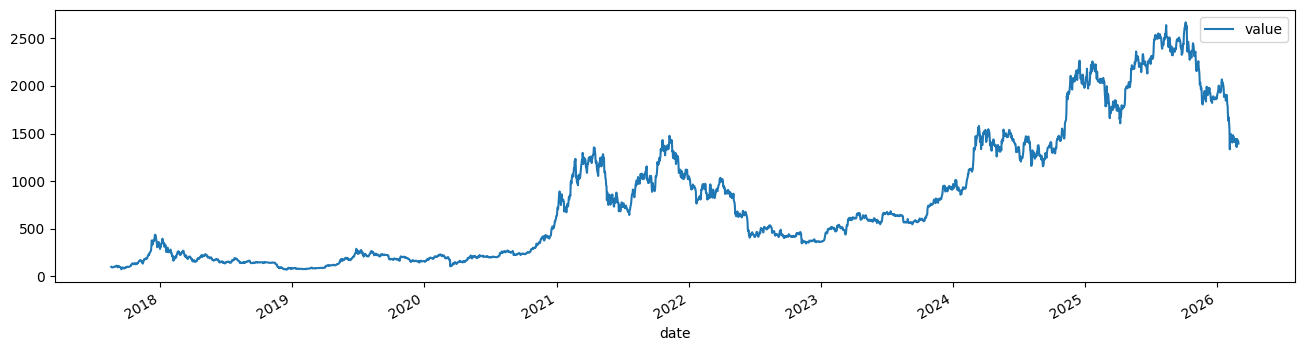

In [2]:
index = pd.read_csv('./index.csv', index_col=0, parse_dates=True)
# Index must be normalized for bt to work (in Binance where the index consists of very high numbers)
index = index / index.iloc[0] * 100  # Normalize to start at 100                                                                                    
index.name = 'value'
print(f'Got index with length {len(index)}')
index.plot(figsize=(16, 4))

  0%|                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 20.72it/s]

Stat                 benchmark
-------------------  -----------
Start                2017-08-17
End                  2026-03-02
Risk-free rate       0.00%

Total Return         1295.75%
Daily Sharpe         0.66
Daily Sortino        1.08
CAGR                 36.16%
Max Drawdown         -83.67%
Calmar Ratio         0.43

MTD                  -0.13%
3m                   -24.02%
6m                   -40.37%
YTD                  -26.03%
1Y                   -23.42%
3Y (ann.)            39.33%
5Y (ann.)            5.82%
10Y (ann.)           36.16%
Since Incep. (ann.)  36.16%

Daily Sharpe         0.66
Daily Sortino        1.08
Daily Mean (ann.)    37.66%
Daily Vol (ann.)     56.80%
Daily Skew           -0.29
Daily Kurt           8.41
Best Day             22.10%
Worst Day            -39.62%

Monthly Sharpe       0.75
Monthly Sortino      1.76
Monthly Mean (ann.)  55.19%
Monthly Vol (ann.)   73.59%
Monthly Skew         0.55
Monthly Kurt         -0.05
Best Month           57.99%
Worst Month   

<Axes: title={'center': 'Equity Progression'}>

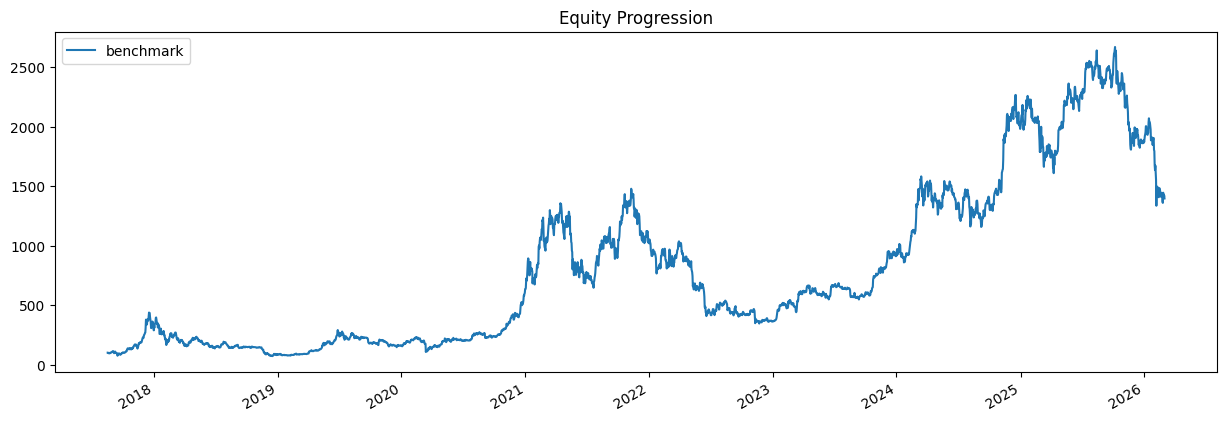

In [3]:
# Benchmark: Our index
import bt
strategy = bt.Strategy(
    'benchmark',
    [
        bt.algos.RunOnce(),
        bt.algos.SelectAll(),
        bt.algos.WeighEqually(),
        bt.algos.Rebalance(),
    ],
)
test = bt.Backtest(strategy, index, initial_capital=100000)
result = bt.run(test)
result.display()
result.plot()

In [4]:
# The paper below favors 28 days as a lookback period and a 5-day holding period. Adding longer
# periods just takes more time, but does not improve the result.
lookback_periods = [10, 20, 30, 45, 60, 75]
index_cagrs = [
    index.rolling(window=lb).apply(simple_regression.create_regression('cagr'))
    for lb in lookback_periods
]
# index_r2s = [
#     index.rolling(window=lb).apply(simple_regression.create_regression('r2'))
#     for lb in lookback_periods
# ]

Go long:
                           value
date                            
2017-11-06 00:00:00+00:00      0
2017-11-13 00:00:00+00:00      0
2017-11-20 00:00:00+00:00      0
2017-11-27 00:00:00+00:00      0
2017-12-04 00:00:00+00:00      0
...                          ...
2026-02-02 00:00:00+00:00      0
2026-02-09 00:00:00+00:00      0
2026-02-16 00:00:00+00:00      0
2026-02-23 00:00:00+00:00      0
2026-03-02 00:00:00+00:00      0

[434 rows x 1 columns]


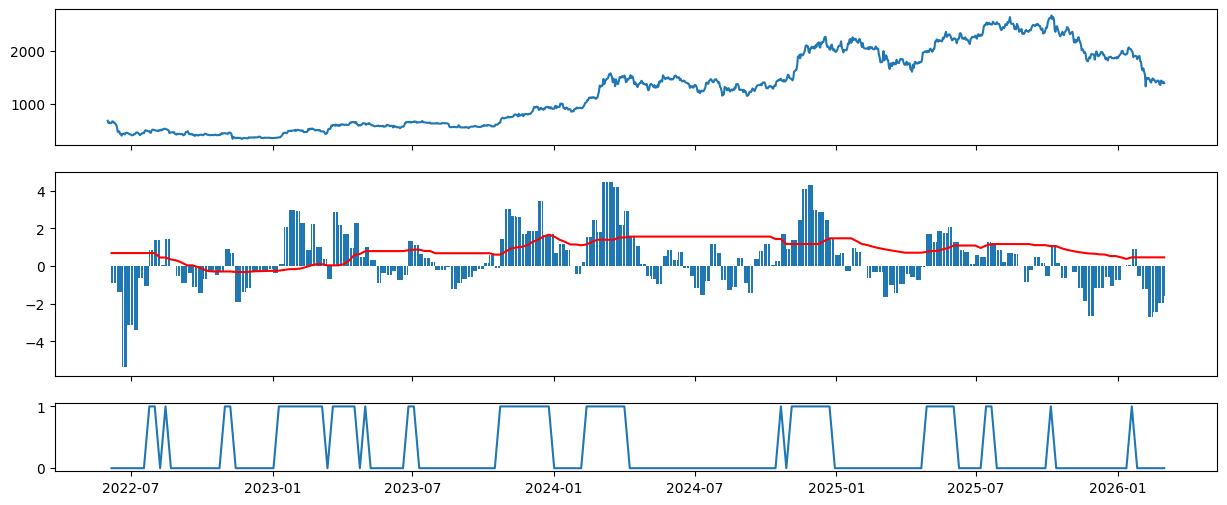

Mean CAGRs - best percentile
We go long if > 0 (and if mean CAGR is > 0)
                              value
date                               
2025-12-29 00:00:00+00:00 -1.288276
2026-01-05 00:00:00+00:00 -0.452355
2026-01-12 00:00:00+00:00 -0.298736
2026-01-19 00:00:00+00:00  0.436712
2026-01-26 00:00:00+00:00 -0.976443
2026-02-02 00:00:00+00:00 -1.692552
2026-02-09 00:00:00+00:00 -3.166941
2026-02-16 00:00:00+00:00 -2.900817
2026-02-23 00:00:00+00:00 -2.444983
2026-03-02 00:00:00+00:00 -2.078022


In [5]:
# Get the mean for the CAGRs and decide when we should go long
mean_cagrs = sum(index_cagrs[:]) / len(index_cagrs[:])
# Only preserve the cells in which there's cagr data for *all* lookback periods (period 10 has
# more data than 75 because the window starts earlier) – use the last lookback period as mask.
mean_cagrs = mean_cagrs[index_cagrs[-1].notna()]
# Terribly dangerous: Never bfill; this would apply future's knowledge to today's data. Always
# ffill (newer dates are lower down in our df)
# Drop all weekdays without data
cleaned_mean_cagrs = mean_cagrs.dropna()

# binary = [np.sign(df).dropna() for df in index_cagrs]
# binary_sum = sum(binary)
# binary_long = binary_sum >= len(lookback_periods)
# print(f'Binary long: {len(binary_long[binary_long].dropna())}')

# Adding r2 does not improve anything
# mean_r2s = sum(index_r2s) / len(index_r2s)
# mean_r2s = mean_r2s[index_r2s[-1].notna()].dropna()

# Go long when cagr is in the top third (compared to the past)
# Inspiration: https://acfr.aut.ac.nz/__data/assets/pdf_file/0009/918729/Time_Series_and_Cross_Sectional_Momentum_in_the_Cryptocurrency_Market_with_IA.pdf
# q67 = cleaned_mean_cagrs.expanding().quantile(0.75)
# Don't look back too far: If the past was too good, there won't be any positions in the future. 
# 100 equals 2 years as we have weekly data (100 weeks = 700 days = 2 years)
best_percent = cleaned_mean_cagrs.rolling(window=50).quantile(2/3)

# Also make sure that values are above/below 0, do not just use the relative ranking.
# Adding r2 (e.g. > 0 or > 0.5) does not improve anything.
is_top = (cleaned_mean_cagrs >= best_percent) & (cleaned_mean_cagrs > 0)
# Buying on growing CAGR does not improve anything
# & (cleaned_mean_cagrs > cleaned_mean_cagrs.shift(1))
go_long = is_top.astype(int)

print('Go long:')
print(go_long)

fig, ax = plt.subplots(3, 1,figsize=(15, 6), sharex=True, gridspec_kw={'height_ratios': [2, 3, 1]})
start = '2022-06-01'
end = None
ax[0].plot(index.loc[start:end])
cagrs_to_plot = cleaned_mean_cagrs['value']
cagrs_to_plot = cagrs_to_plot.loc[start:end].reindex(index.loc[start:end].index).ffill()
ax[1].bar(cagrs_to_plot.index, cagrs_to_plot.values)
ax[1].plot(best_percent[start:end], color='red')
ax[2].plot(go_long.loc[start:end])
plt.show()

print('Mean CAGRs - best percentile\nWe go long if > 0 (and if mean CAGR is > 0)')
print((cleaned_mean_cagrs - best_percent).iloc[-10:])

  0%|                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.32it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.30it/s]

Stat                 ledoit_wolf
-------------------  -------------
Start                2017-08-17
End                  2026-03-02
Risk-free rate       0.00%

Total Return         2598.81%
Daily Sharpe         1.07
Daily Sortino        1.79
CAGR                 47.09%
Max Drawdown         -45.33%
Calmar Ratio         1.04

MTD                  0.00%
3m                   -7.71%
6m                   -14.06%
YTD                  -7.71%
1Y                   -1.85%
3Y (ann.)            33.06%
5Y (ann.)            18.65%
10Y (ann.)           47.09%
Since Incep. (ann.)  47.09%

Daily Sharpe         1.07
Daily Sortino        1.79
Daily Mean (ann.)    30.69%
Daily Vol (ann.)     28.59%
Daily Skew           1.01
Daily Kurt           20.04
Best Day             17.31%
Worst Day            -14.28%

Monthly Sharpe       1.07
Monthly Sortino      4.34
Monthly Mean (ann.)  46.78%
Monthly Vol (ann.)   43.70%
Monthly Skew         2.48
Monthly Kurt         7.10
Best Month           57.98%
Worst Month   

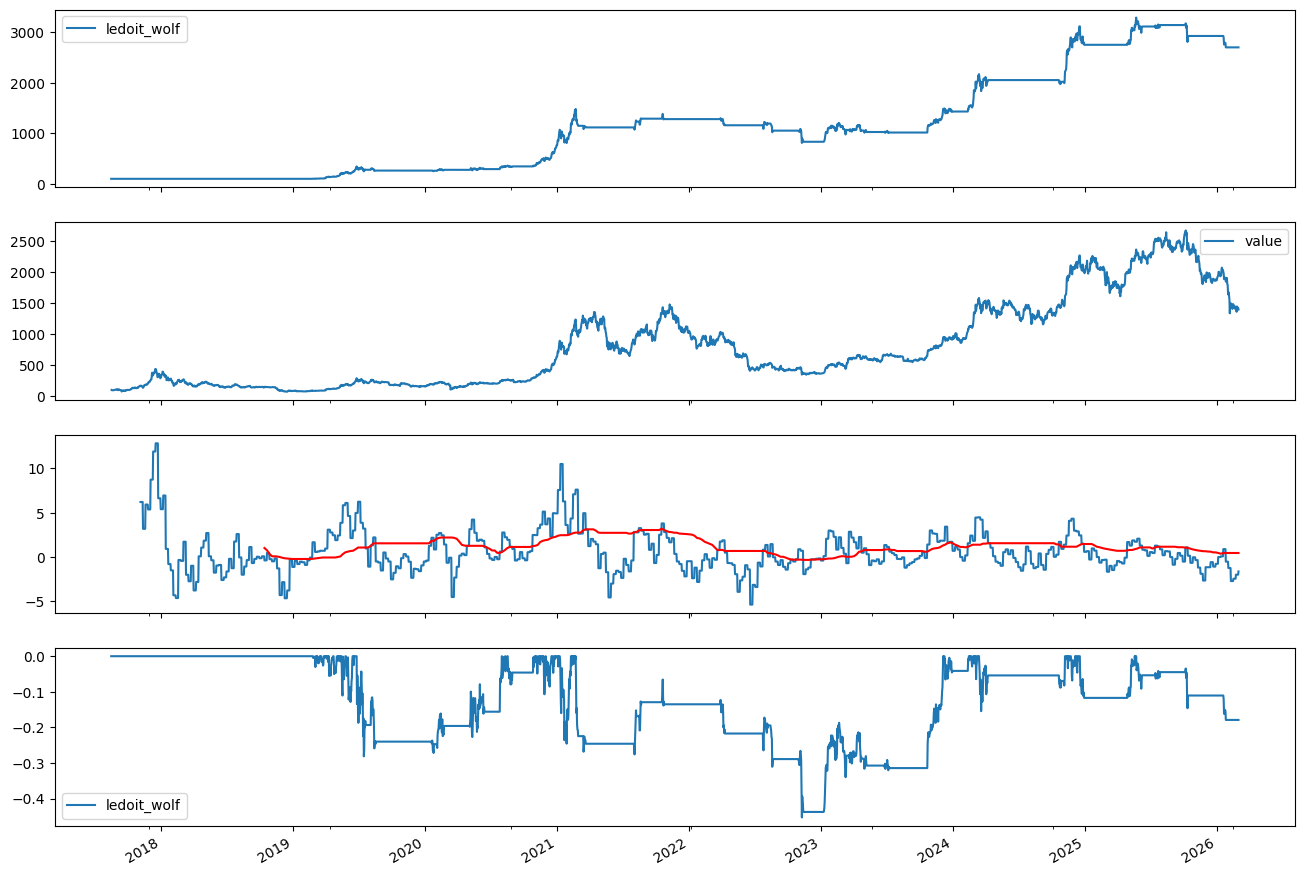

In [6]:
# See how we'd perform if we held the index on good times (top CAGR periods)
index_result = backtest.run('ledoit_wolf', index, go_long)
index_result.display()

index_rolling_max = index_result.prices.cummax()
index_drawdowns = (index_result.prices - index_rolling_max) / index_rolling_max

fig, ax = plt.subplots(4, 1,figsize=(16, 12), sharex=True)
index_result.prices.plot(ax=ax[0])
index.plot(ax=ax[1])
# ax[1].bar(mean_cagrs['value'].index, mean_cagrs['value'].values)
ax[2].plot(mean_cagrs.ffill())
ax[2].plot(best_percent, color='red')
index_drawdowns.plot(ax=ax[3])
plt.show()

In [7]:
# If we're not going long, we can stop here (no complex calculations and distribution needed)
# if go_long.iloc[-1].item() == 0:
#     sys.exit("Stopping execution because condition is met")

# Calculate CAGR / R2 for all index constituents
index_weights = pd.read_csv('index_weights.csv', index_col=0)
# Drop all cols that dont belong to the index
index_weights = index_weights.dropna(axis=1, how='all')
constituent_names = index_weights.columns.to_list()
print(f'{len(constituent_names)} index constituents are {constituent_names}')

data_dir = os.path.join(base_dir, f'../{exchange.lower()}_data/')
print(f'Data dir is {data_dir}')
closes = coinbase_reader.read('close', data_dir=data_dir, exchange=exchange, base_currency=base_currency)
constituent_closes = closes[constituent_names]

print(f'Use {len(constituent_closes.columns)} cryptos with {len(closes)} rows')

# For simple experiments, limit our dataset
# lookback_periods = [75]
# constituent_closes = closes[['ETH']]

constituent_cagrs = []
constituent_r2s = []
for lb in lookback_periods:
    start_time = time.time()
    print(f'Starting lookback period {lb} …')
    constituent_cagrs.append(
        constituent_closes.rolling(window=lb).apply(simple_regression.create_regression('cagr'))
    )
    # constituent_r2s.append(
    #     constituent_closes.rolling(window=lb).apply(simple_regression.create_regression('r2'))
    # )
    print(f'Lookback period {lb} done after {round(time.time() - start_time)} seconds')

99 index constituents are ['1000SATS', 'AAVE', 'ADA', 'ADADOWN', 'ALGO', 'ANC', 'APE', 'APT', 'ARB', 'ATOM', 'AVAX', 'BAND', 'BCC', 'BNB', 'BNBDOWN', 'BOME', 'BONK', 'BTC', 'BTCDOWN', 'BTT', 'CELR', 'CFX', 'CHZ', 'DASH', 'DOGE', 'DOT', 'DOTDOWN', 'DYDX', 'ENA', 'EOS', 'ETC', 'ETH', 'ETHDOWN', 'EUR', 'FDUSD', 'FET', 'FIL', 'FLOKI', 'FTM', 'GALA', 'GMT', 'HBAR', 'ICX', 'INJ', 'IOST', 'IOTA', 'JASMY', 'LDO', 'LINK', 'LRC', 'LTC', 'LUNA', 'MANA', 'MASK', 'MATIC', 'NEAR', 'NEIRO', 'NEO', 'NOT', 'OM', 'OMG', 'ONT', 'OPTIM', 'ORDI', 'PAX', 'PENGU', 'PEOPLE', 'PEPE', 'PNUT', 'QTUM', 'RUNE', 'SAND', 'SEI', 'SHIB', 'SLP', 'SOL', 'SOMI', 'SUI', 'SUSHI', 'SXP', 'TAO', 'TIA', 'TRB', 'TRUMP', 'TRX', 'UNI', 'USD1', 'VET', 'WAVES', 'WIF', 'WIN', 'WLD', 'WLFI', 'XLM', 'XMR', 'XRP', 'XTZ', 'YFI', 'ZEC']
Data dir is /Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/src/../binance_data/
Got 649 historical files
Remove BINANCE_SPOT_ and _USDT
Read files [['LQTY', '/Users/fs/Documents/Aktien/Code/Python

Use 99 cryptos with 3118 rows
Starting lookback period 10 …


Lookback period 10 done after 1037 seconds
Starting lookback period 20 …


Lookback period 20 done after 62 seconds
Starting lookback period 30 …


Lookback period 30 done after 82 seconds
Starting lookback period 45 …


Lookback period 45 done after 2004 seconds
Starting lookback period 60 …


Lookback period 60 done after 381 seconds
Starting lookback period 75 …


Lookback period 75 done after 262 seconds


In [8]:
# fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
# ax[0].plot(constituent_closes[['ETH', 'BTC']].loc[start:end])
# ax[1].plot(constituent_cagrs[0][['ETH', 'BTC']].loc[start:end].ffill())
# plt.show()

/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u *

/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/fs/Documents/Aktien/Code/Python/2025-11-crypto/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u *

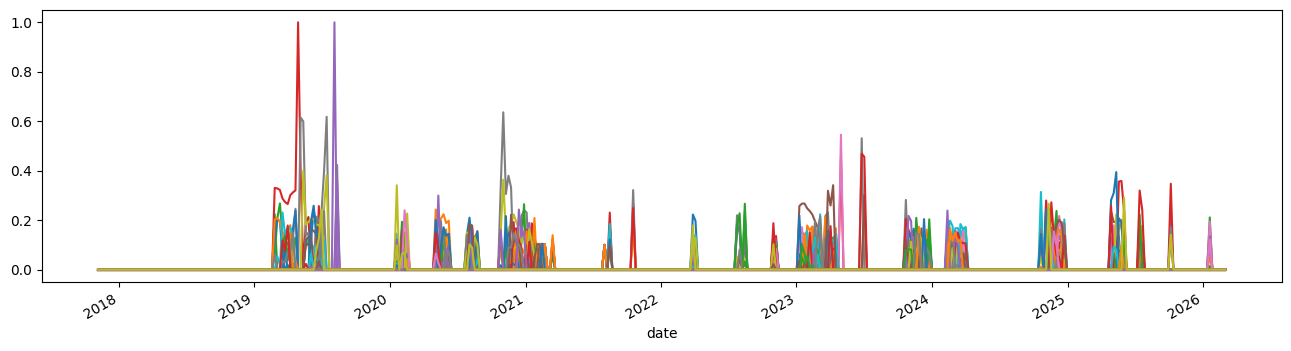

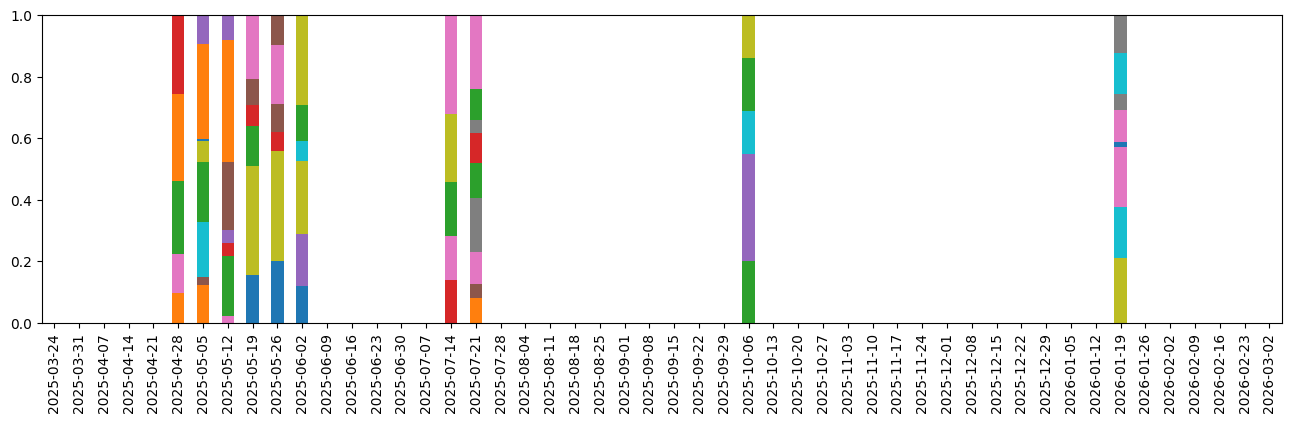

In [9]:
# With lookback period 10, we have more data than with lookback period 75. Why? Because we can
# start our calculations earlier (after 10 rows of non-nan data). Make sure we only preserve cells
# that have data in *all* lookback periods.
cagr_mask = np.logical_and.reduce([~df.isna() for df in constituent_cagrs])
# Apply the mask to each df
cleaned_constituent_cagrs = [df.where(cagr_mask) for df in constituent_cagrs]
mean_constituent_cagrs = sum(cleaned_constituent_cagrs[:-2]) / len(cleaned_constituent_cagrs[:-2])
mean_constituent_cagrs = mean_constituent_cagrs.dropna(how='all')

# r2_mask = np.logical_and.reduce([~df.isna() for df in constituent_r2s])
# cleaned_constituent_r2s = [df.where(r2_mask) for df in constituent_r2s]
# mean_constituent_r2s = sum(cleaned_constituent_r2s) / len(cleaned_constituent_r2s)
# mean_constituent_r2s = mean_constituent_r2s.dropna(how='all')

# Create default weights table with value 0
weights = pd.DataFrame(index=go_long.index, columns=constituent_names)
weights[:] = 0

# Window of 50 = 1 year lookback
# crypto_percentiles = mean_constituent_cagrs.rolling(window=100).quantile(0.75)

# up_cagrs = mean_constituent_cagrs > mean_constituent_cagrs.shift(1)

# Whenever the index tells us to go long, get the best performing cryptos (that are part of the
# index) at that time. 
# go_long is a df, we only need the first column (therefore the brackets).
for date, [is_long] in go_long.iterrows():
    if is_long == 1:
        # Get the best performing cryptos
        current_cagrs = mean_constituent_cagrs.loc[date]
        # current_cagrs = current_cagrs[up_cagrs.loc[date]]

        # current_r2s = mean_constituent_r2s.loc[date]
        # current_cagrs = current_cagrs[current_r2s > 0]
        # top_cagrs = current_cagrs[current_cagrs > crypto_percentiles.loc[date]]
        best_cryptos = current_cagrs.sort_values(ascending=False)

        best_cryptos = best_cryptos.dropna()
        # Remove all cryptos with a cagr < x; why x=2? Because it works well.
        best_cryptos = best_cryptos[best_cryptos > 2]
        best_cryptos = best_cryptos[:10]
        # Reduce weights of single instruments
        # best_cryptos = best_cryptos ** 0.5
        # Equal weights
        # best_cryptos[:] = 1
        # Normalize to sum of 1
        # print(f'Best performing on {date.date()}: {best_cryptos.to_dict()}')

        ledoit_period = pd.Timedelta(days=100)
        data_for_ledoit = constituent_closes.loc[date-ledoit_period:date, best_cryptos.index]

        ledoit_weights = ledoit_wolf.calculate_weights(data_for_ledoit)
        # print('Max Div', best_cryptos.index.to_list(), ledoit_weights)

        # changes = data_for_ledoit.pct_change().dropna()
        # cov_matrix_lw = risk_models.CovarianceShrinkage(data_for_ledoit).ledoit_wolf()

        # if (len(changes.columns) == 1):
        #     hrp_weights = [1]
        # else:
        #     hrp = HRPOpt(returns=changes, cov_matrix=cov_matrix_lw)
            # HRP.optimize returns an OrderedDict; just get the list of values.
        #     hrp_weights = list(hrp.optimize().values())
        # print('HRP', best_cryptos.index.to_list(), hrp_weights)

        # You can drop in hrp_weights here – but it does not improve anything
        weights.loc[date, best_cryptos.index] = ledoit_weights

        # best_cryptos = best_cryptos / best_cryptos.sum()
        # weights.loc[date, best_cryptos.index] = best_cryptos.values

# No weight over 25%, ever
# Does not improve anything.
# weights[weights > 0.2] = 0.2

weights.to_csv('weights.csv')

weights.plot(figsize=(16, 4), legend=False)
plt.show()

last_weights = weights[-50:]
last_weights.index = last_weights.index.date
# Drop all cols only containing 0
last_weights = last_weights.loc[:, (last_weights != 0).any(axis=0)]
last_weights.plot(kind='bar', stacked=True, figsize=(16, 4), legend=False)
plt.show()

In [10]:
current_weights = weights.iloc[-1]
current_weights = current_weights[current_weights != 0]
percentages = [f'{label}: {(value * 100):.1f}%' for (label, value) in current_weights.items()]
print(f'Current weights on {current_weights.name}: {percentages}')
current_balance = 35_900
current_distribution = [f'{label}: {value:.0f}' for (label, value) in (current_balance * current_weights).items()]
print(f'Current distribution:\n{current_distribution}')

Current weights on 2026-03-02 00:00:00+00:00: []
Current distribution:
[]


/var/folders/nm/gwt2t49543q2yjhmky858jf80000gn/T/ipykernel_14381/205630929.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  weights = weights.reindex(constituent_closes.index).ffill().fillna(0)


  0%|                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.36it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.35it/s]

Stat                 trend_following_index
-------------------  -----------------------
Start                2017-08-17
End                  2026-03-02
Risk-free rate       0.00%

Total Return         76340.49%
Daily Sharpe         1.39
Daily Sortino        2.44
CAGR                 117.60%
Max Drawdown         -40.70%
Calmar Ratio         2.89

MTD                  0.00%
3m                   -14.21%
6m                   -6.44%
YTD                  -14.21%
1Y                   39.06%
3Y (ann.)            91.09%
5Y (ann.)            74.53%
10Y (ann.)           117.60%
Since Incep. (ann.)  117.60%

Daily Sharpe         1.39
Daily Sortino        2.44
Daily Mean (ann.)    64.07%
Daily Vol (ann.)     45.97%
Daily Skew           1.25
Daily Kurt           15.76
Best Day             28.68%
Worst Day            -19.83%

Monthly Sharpe       1.20
Monthly Sortino      6.08
Monthly Mean (ann.)  107.19%
Monthly Vol (ann.)   89.48%
Monthly Skew         2.77
Monthly Kurt         9.45
Best Month      

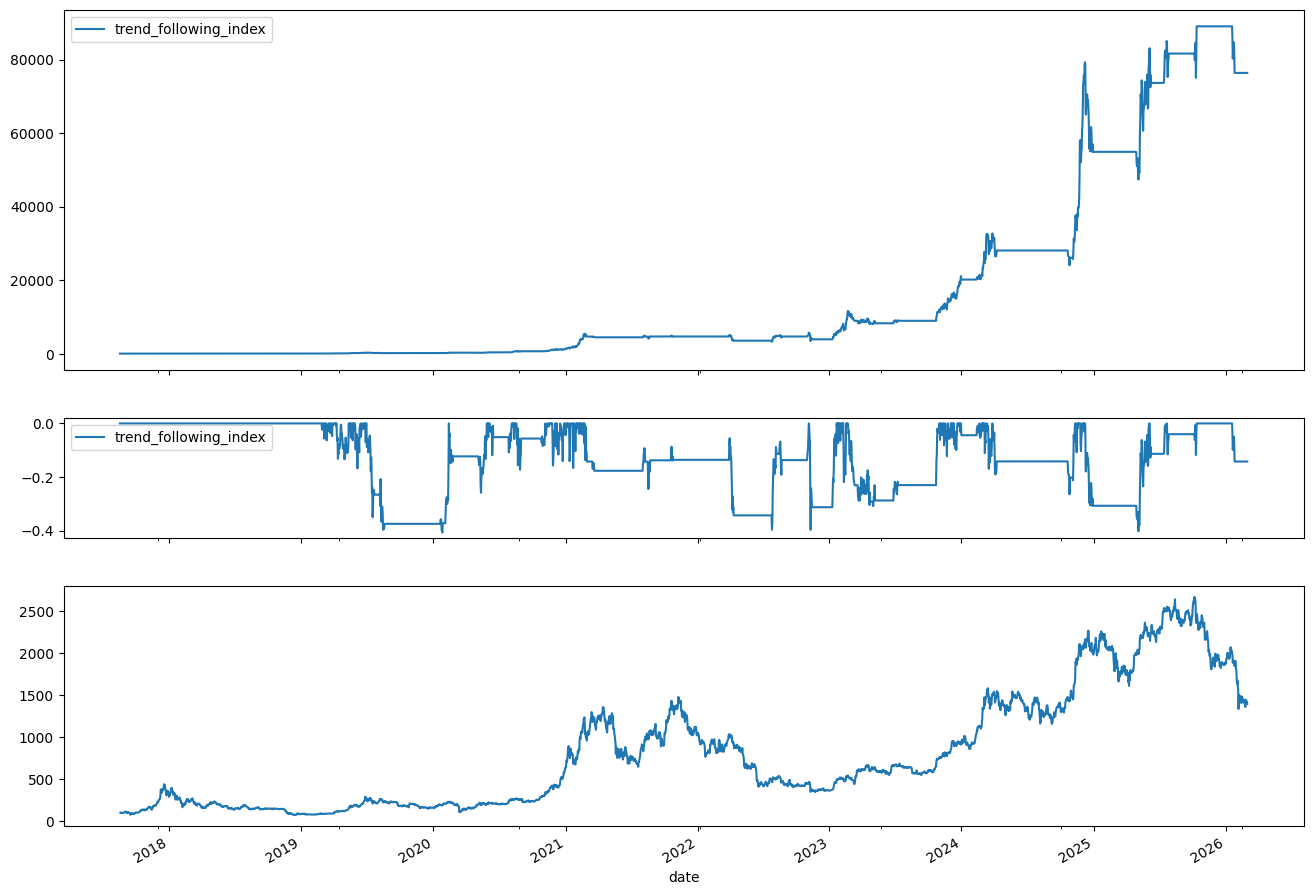

In [11]:
# Make very sure that we have weights on all dates that we could trade because there's date to 
# do so.
# Terribly dangerous: Never bfill; this would apply future's knowledge to today's data. Always
# ffill (newer dates are lower down in our df)
weights = weights.reindex(constituent_closes.index).ffill().fillna(0)
constituent_closes = constituent_closes.ffill()

result = backtest.run('trend_following_index', constituent_closes, weights)
result.display()

rolling_max = result.prices.cummax()
drawdowns = (result.prices - rolling_max) / rolling_max
print('Latest prices')
print(result.prices.tail(20))
result_weights = result.get_security_weights()

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1, 2]})
result.prices.plot(ax=ax[0], label='prices')
drawdowns.plot(ax=ax[1])
index.plot(ax=ax[2], legend=False)
plt.show()